In [757]:
import numpy as np
import matplotlib.pyplot as plt     

In [6]:
%%bash
cd ..
g++ -std=c++17 -Wall Curve.cpp SRC/Mesh.cpp SRC/Flux.cpp SRC/Simulation.cpp SRC/Solver.cpp SRC/Cell.cpp -o Curvilinear

        

Curve.cpp: In function ‘int main()’:
Curve.cpp:28:11: warning: unused variable ‘iterator’ [-Wunused-variable]
   28 |     Cell* iterator = test.simulation_mesh.interior_cells[0];
      |           ^~~~~~~~
SRC/Flux.cpp: In member function ‘void Flux::compute_residual()’:
SRC/Flux.cpp:451:14: warning: unused variable ‘ghost_flag’ [-Wunused-variable]
  451 |         bool ghost_flag = false;
      |              ^~~~~~~~~~


In [7]:
%%bash
cd ..
./Curvilinear

terminate called after throwing an instance of 'nlohmann::json_abi_v3_12_0::detail::parse_error'
  what():  [json.exception.parse_error.101] parse error at line 1, column 1: attempting to parse an empty input; check that your input string or stream contains the expected JSON
bash: line 2: 2603818 Aborted                 (core dumped) ./Curvilinear


CalledProcessError: Command 'b'cd ..\n./Curvilinear\n'' returned non-zero exit status 134.

In [760]:
rho = 0.761065
u   = 34.6842
v   = 34.6842
p   = 65396.9

cell_R = np.array([rho,u,v,p])
cell_L = np.array([.7648,0,0,65855])



In [761]:


data = np.loadtxt("primitives.csv", delimiter=",")
NI = 32
NJ = 32
print(data.shape)   # (4, Ncells)
rho = data[0, :].reshape((NI,NJ))
u   = data[1, :].reshape((NI,NJ))
v   = data[2, :].reshape((NI,NJ))
p   = data[3, :].reshape((NI,NJ))


(4, 1024)


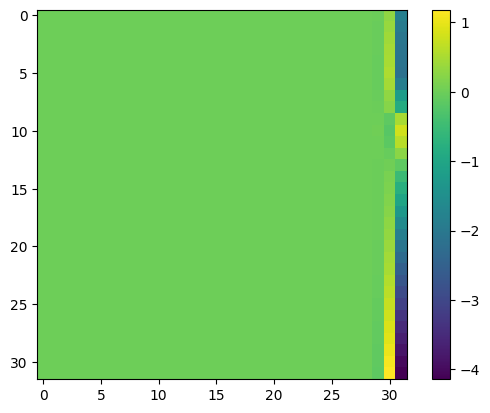

In [762]:
p = p.reshape((32,32))
plt.imshow(v)
plt.colorbar()

In [763]:
vanleer_flux_cell(cell_L,cell_R,-1,1)+vanleer_flux_cell(cell_R,cell_L,1,-1)

array([0., 0., 0., 0.])

In [764]:
epsilon = 1e-10
gamma = 1.4
def vanleer_flux_cell(CELL_L,CELL_R,nx,ny):
    return f_convective_cell(CELL_L,CELL_R, nx,ny)+f_pressure_flux_cell(CELL_L,CELL_R, nx,ny)

def f_pressure_flux_cell(CELL_L,CELL_R,nx,ny):

    rho_L,rho_R = CELL_L[0],CELL_R[0]
    u_L,u_R = CELL_L[1],CELL_R[1]
    v_L,   v_R   = CELL_L[2], CELL_R[2]  # y-velocity
    p_L,   p_R   = CELL_L[3], CELL_R[3] 
    if np.any(rho_L<=0):
        rho_L = np.maximum(rho_L, epsilon)
    if np.any(rho_R<=0):
        rho_R = np.maximum(rho_R, epsilon)



    
    U_L = u_L*nx +ny*v_L
    U_R = u_R*nx+ny*v_R
    
    a_L = np.sqrt(np.maximum(epsilon,(gamma*(p_L/rho_L))))
    a_R = np.sqrt(np.maximum(epsilon,(gamma*(p_R/rho_R))))
    M_L,M_R = (U_L/a_L,U_R/a_R)
    
    alpha_plus = .5*(1+np.sign(M_L))
    alpha_minus = .5*(1-np.sign(M_R))
    beta_L = -np.maximum(0,1-np.floor(np.abs(M_L)))
    beta_R = -np.maximum(0,1-np.floor(np.abs(M_R)))

    M_plus = .25*(M_L+1)**2
    M_minus = -.25*(M_R-1)**2

    p_doubleBar_plus = M_plus*(-M_L+2)
    p_doubleBar_minus = M_minus*(-M_R-2)

    D_plus = alpha_plus*(1+beta_L)-beta_L*p_doubleBar_plus
    D_minus = alpha_minus*(1+beta_R)-beta_R*p_doubleBar_minus

    temp_zero = np.zeros_like(p_L)
    

    return np.array([temp_zero,nx*D_plus*p_L,ny*D_plus*p_L,temp_zero])+\
        np.array([temp_zero,nx*D_minus*p_R,ny*D_minus*p_R,temp_zero])

def c_plus_minus(alpha_plus_minus,beta_LR,mach_LR,M_plus_minus):
    return alpha_plus_minus*(1+beta_LR)*mach_LR-beta_LR*M_plus_minus


def f_convective_cell(CELL_L,CELL_R,nx,ny):
    rho_L,rho_R = CELL_L[0],CELL_R[0]
    u_L,u_R = CELL_L[1],CELL_R[1]
    v_L,   v_R   = CELL_L[2], CELL_R[2]  # y-velocity
    p_L,   p_R   = CELL_L[3], CELL_R[3] 
    if np.any(rho_L<=0):
        rho_L = np.maximum(rho_L, epsilon)
    if np.any(rho_R<=0):
        rho_R = np.maximum(rho_R, epsilon)
    
    U_L = u_L*nx +ny*v_L
    U_R = u_R*nx +ny*v_R



    a_L = np.sqrt(np.maximum(epsilon,(gamma*(p_L/rho_L))))
    a_R = np.sqrt(np.maximum(epsilon,(gamma*(p_R/rho_R))))
    M_L,M_R = (U_L/a_L,U_R/a_R)
    
    alpha_plus = .5*(1+np.sign(M_L))
    alpha_minus = .5*(1-np.sign(M_R))
    beta_L = -np.maximum(0,1-np.floor(np.abs(M_L)))
    beta_R = -np.maximum(0,1-np.floor(np.abs(M_R)))

    M_plus = .25*(M_L+1)**2
    M_minus = -.25*(M_R-1)**2

    
    ht_L = (gamma / (gamma - 1)) * (p_L / rho_L) + 0.5 * (u_L**2+v_L**2)
    ht_R = (gamma / (gamma - 1)) * (p_R / rho_R) + 0.5 * (u_R**2+v_R**2)

    temp_L = rho_L*a_L*c_plus_minus(alpha_plus,beta_L,M_L,M_plus)
    temp_R = rho_R*a_R*c_plus_minus(alpha_minus,beta_R,M_R,M_minus)
    FC_i_half = np.array([temp_L,u_L*temp_L,v_L*temp_L,ht_L*temp_L])+np.array([temp_R,u_R*temp_R,v_R*temp_R,ht_R*temp_R])

    return FC_i_half 

def prim_to_cons(W, gamma=1.4):
    """
    W: iterable of length 4 -> [rho, u, v, p]
    returns [rho, rho*u, rho*v, rho*E]
    """
    rho, u, v, p = W
    rho_u = rho * u
    rho_v = rho * v
    rho_E = p / (gamma - 1.0) + 0.5 * rho * (u*u + v*v)  # rho*e + kinetic
    return [rho, rho_u, rho_v, rho_E]


def cons_to_prim(U, gamma=1.4):
    """
    U: iterable of length 4 -> [rho, rho*u, rho*v, rho*E]
    returns [rho, u, v, p]
    """
    rho, rho_u, rho_v, rho_E = U

    if rho <= 0:
        raise ValueError(f"Nonphysical density: rho = {rho}")

    u = rho_u / rho
    v = rho_v / rho
    kinetic = 0.5 * rho * (u*u + v*v)
    internal = rho_E - kinetic

    if internal <= 0:
        raise ValueError(f"Nonphysical internal energy: e = {internal/rho} from total E = {rho_E}")

    p = (gamma - 1.0) * internal
    return [rho, u, v, p]


In [765]:
def load_grid(filename):

    with open(filename, 'r') as f:
        # Read integers
        nzones = int(f.readline())
        imax, jmax, kmax = map(int, f.readline().split())

        size = imax * jmax * kmax

        # Read the flattened data for x, y, and zztemp
        data = []
        while len(data) < 3 * size:
            line = f.readline()
            data.extend(map(float, line.split()))

        # Split data into x, y, zztemp
        data = np.array(data)
        x = data[0:size].reshape((kmax, jmax, imax))
        y = data[size:2*size].reshape((kmax, jmax, imax))
        zztemp = data[2*size:].reshape((kmax, jmax, imax))

    return x[0],y[0]
x,y = load_grid("/home/aaron99/src/CFD/CFD/CFD_FINAL2/Meshes/curv2d33.grd")

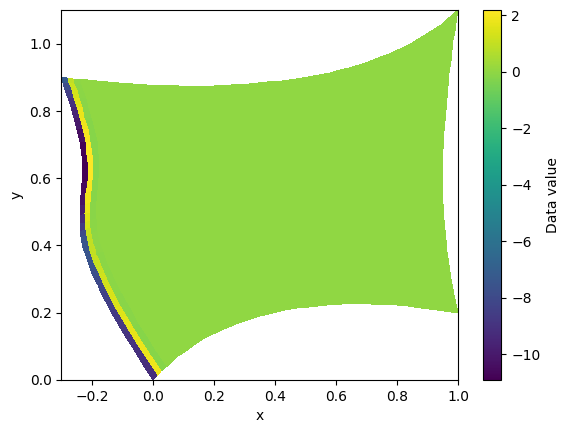

In [766]:
 

plt.pcolormesh(x[:,:], y[:,:], u[:,:], shading='auto', cmap='viridis')
plt.colorbar(label="Data value")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

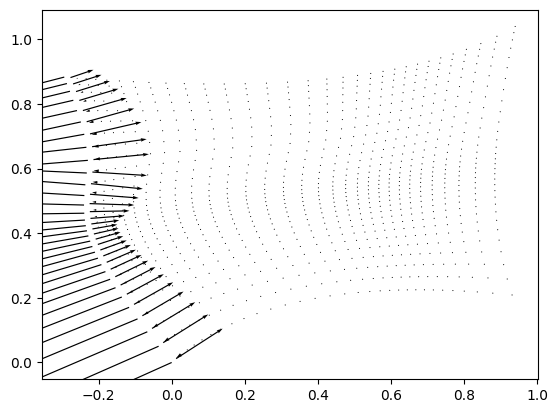

In [767]:
plt.quiver(x[1:,1:],y[1:,1:],u,v)